# Evaluación de la pérdida de calidad del audio usando el codec Opus en tareas de auscultación remota

<a href="https://juanfonsecasolis.github.io/">Juan M. Fonseca-Solís</a> · agosto 2020 (última vez actualizado en agosto 2026)

---

## Introducción

Con el fin de satisfacer la demanda de hospitales y clínicas que buscan auscultar a los pacientes de forma remota, la industria médica se ha dedicado al desarrollo de estetoscopios digitales. El desarrollo de estos aparatos involucra no solo la construcción del hardware, sino también el desarrollo de la infraestructura necesaria para transferir los datos hacia la consulta médica tradicional o automatizada mediante inteligencia artificial. Parte de esta infraestructura involucra el uso del códec Opus, que también se emplea en plataformas de videollamada como Zoom, MS Teams y Skype, por su rendimiento frente a otros algoritmos de compresión de audio "con pérdida". En este notebook determinamos una tasa de bits que puede emplearse para evitar distorsiones producidas por _aliasing_, es decir, plegamiento de las frecuencias altas hacia abajo. Realizamos experimentos con barridos de frecuencia y de voz. 

<img src='2017-08-30-07-09-32.jpeg' width='500'/>

Figura 1. Tomada de https://pixnio.com/es/ciencia/ciencia-medica/estetoscopio-telefono-movil-diagnostico-pulso-cardiologia-medicina-atencion-medica.

# Transmisión del audio 

## Transmisión sin pérdida

Para auscultar a un paciente remotamente, lo ideal sería transmitir audio en formato crudo, es decir, sin compresión alguna. Esto se podría lograr transmitiendo audio en formato _Waveform Audio File_ (WAV), lo cual requiere 1,35 Mbps o megabits por segundo (1 canal, 44100 muestras por segundo y 32 bits de cuantización), lo que para una clínica rural con una conexión de 1,4 Mbps (el máximo permitido para 3.5G) significaría consumir casi el 96% del ancho de banda y quedarse sin video durante la llamada [17].<sup>1</sup> Para ilustrar lo molesto que sería esto, proponemos el siguiente diálogo imaginario entre una clínica y un médico:

> Médico (o el sistema): —Muy bien, vamos a realizar la auscultación. Clínica, apague su cámara (yo voy a apagar la mía). Muy bien, ahora espere un momento... voy a activar el modo "estetoscopio". Listo, proceda a colocar el estetoscopio digital en el espacio intercostal izquierdo de la línea medioclavicular e indíqueme para grabar.— 
>
> Clínica: —Listo doctor, el aparato está ubicado en la zona.—
>
> Médico: —Ok, no puedo ver, pero confío en que ubicó el aparato en la zona que le indiqué.—
>
> Clínica: —Listo doctor, puede comenzar a grabar.—
>
> Médico (1 minuto después): —Ok, ahora repitamos en esta otra zona...—

Terrible, ¿no es así? Y confiemos en que la clínica no va a recibir un correo electrónico que pueda interrumptir la transmisión mientras se ausculta al paciente.

![](dt_140326_doctor_mistake_250x188.png)

Figura 5. Posiblemente cómo se vería nuestro médico auscultando remotamente y sin video a nuestro paciente. Tomada de https://output.com/blog/9-sound-design-tips-to-hack-your-listeners-ears.

## Transmisión con pérdida

A diferencia de WAV, el formato Opus transmite audio comprimido "con pérdida", es decir, reduciendo el tamaño de las grabaciones eliminando información inaudible para el oído humano. Esta compresión funciona aprovechando la forma en la que está diseñada la cóclea, que, como muestra la figura 3, es un órgano en forma cónica encargado de percibir las frecuencias y transmitirlas como impulsos eléctricos al cerebro. La cóclea se encuentra "arrollada" dentro del oído interno y recibe estímulos del oído externo e intermedio mediante la ventana oval. La ventana oval se conecta a su vez con los huesecillos que reciben estímulos del tímpano y que flotan en un medio acuoso.

<img src='800px-Anatomy_of_the_Human_Ear.svg.png' width='500'/>

Figura 3. Tomada de https://en.wikipedia.org/wiki/Auditory_system#/media/File:Anatomy_of_the_Human_Ear.svg.

La cóclea, como explica la teoría psicoacústica, sufre dos efectos llamados _enmascaramiento frecuencial_ y _enmascaramiento temporal_. El primero ocurre cuando dos tonos están lo suficientemente cercanos y el de mayor energía logra cubrir con su envolvente espectral al de menor energía, enmascarándolo. La figura 4 ilustra que este efecto solo se logra cuando ambos tonos comparten la misma _banda crítica_, que está dividida en 32 regiones en las que está dividida la cóclea, y que "resuenan" con mayor facilidad a una frecuencia característica. Dos ejemplos de bandas críticas son: [500, 7000] Hz con frecuencia central de 500 Hz y [8900,10400] Hz con frecuencia central de 9600 Hz [10].

<img src='QA_2-0112.jpeg' width='500'/>

Figura 4. Ilustración del audio interno, medio y externo (tomada de https://output.com/blog/9-sound-design-tips-to-hack-your-listeners-ears).  

La longitud y la localización de las bandas críticas han sido aproximadas en unas escalas numéricas llamadas Bark y ERB. Estas escalas se basan en el hecho de que el oído humano realiza un mejor trabajo diferenciando tonos graves de tonos agudos (como siguiendo una distribución logarítmica). La escala *Equivalent Rectangular Bandwidth* (ERB) es una versión mejorada de la escala Bark y su ecuación es la siguiente [9]: 

$$\text{ERB}(f)=21.4 \log_{10}{(0.00437f+1)}.$$

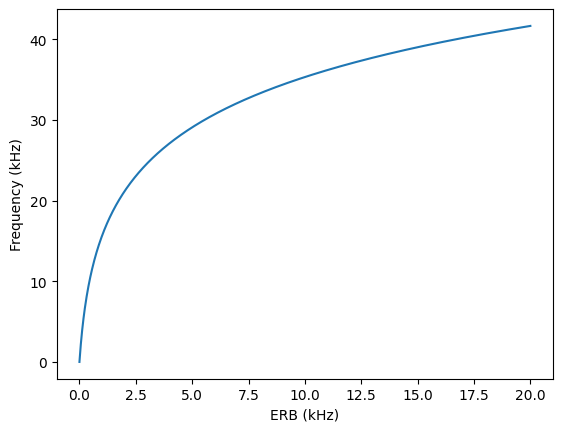

[    0    35    76   124   179   242   315   400   498   611   742   893
  1068  1270  1503  1772  2083  2443  2859  3339  3894  4536  5277  6134
  7123  8267  9589 11116 12881 14920 17276 20000]


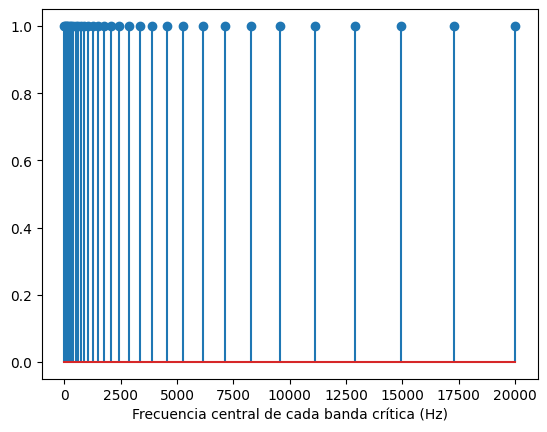

In [9]:
import numpy as np
from numpy import ndarray
import matplotlib.pylab as plt

def erb(F:float) -> ndarray:
    return 21.4 * np.log10(0.00437*F+1)

F = np.linspace(0,20000,1000) # 0 a 20k Hz es el rango de audición humana
E = erb(F)
plt.plot(F/1e3,E)
plt.ylabel('Frequency (kHz)')
plt.xlabel('ERB (kHz)')
plt.show()

E = np.linspace(0,erb(20000),32) # 32 puntos equidistantes
F = (np.power(10,E/21.4)-1)/0.00437 # invertimos el logaritmo de la escala ERB
print(F.astype(int))
plt.stem(F,np.ones(len(F)))
plt.xlabel('Frecuencia central de cada banda crítica (Hz)')
plt.show()

## El códec Opus

Opus surgió como una alternativa a otros formatos de compresión, como el _MPEG Layer 3_ (MP3), el _Advance Audio Coding_ (AAC) o el Vorbis, y se ha preferido por su rendimiento superior en todo el rango de transmisión de bits (figura 2). Fue publicado en 2013 por Valin et al. en la conferencia 135 de la Audio Engineering Society. Opus se basa en dos algoritmos desarrollados previamente: [SILK](https://github.com/ploverlake/silk), para la compresión de voz (originalmente desarrollado por Skype), y *Constrained Energy Lapped Transform* (CELT), para la compresión de música, así como un modo híbrido [3, 4, 13].<sup>2</sup>  

<img src='qualityOpus.png' width='500'/>

Figura 2. Rendimiento del algoritmo Opus (tomado del sitio de Opus https://opus-codec.org/static/comparison/quality.svg).

# Compresión a diferentes tasas de bits

Opus puede ajustarse a diferentes tasas de bits. Por ejemplo, a 8 kbps puede transmitir audio de calidad telefónica analógica entre dos personas (hasta 3200 Hz) y a 128 kbps puede enviar audio en calidad estéreo de banda completa (hasta 20 kHz) [12, 20]. A continuación, realizamos una prueba de transmisión a esas dos tasas de bits usando un barrido de frecuencias en el rango de [10, 20000] Hz, pues este rango abarca el espectro de sonidos del corazón, en [20, 500] Hz, los pulmones, en [10, 2000] Hz, y la voz, en [20, 20000] Hz [14, 15].<a href="#footnote-3"><sup>3</sup></a> 

## Barrido de frecuencias a evaluar

Construimos el barrido usando un tono puro senoidal de la forma $x[t] = \sin(2\pi F(t) t)$, con la tasa de cambio de la frecuencia fundamental, $F(t)$, como sigue [6]:<a href="#footnote-4"><sup>4</sup></a>
$$
F(t) = \Big(\frac{F_1-F_0}{T}\Big)t + F_0.
$$

**Nota: a partir de este momento se recomienda bajar el volumen del audio si se están usando audífonos.**

In [10]:
from scipy.io import wavfile
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt
import os

rango = [10, 20e3] # el rango promedio de audición humano en Hz
Fs = 44.1 * 1e3 # la tasa de muestreo de los equipos comerciales
T = 1.0 # segundos (t1-t0)

N = int(T*Fs)
n = np.arange(0,N)
F0 = (rango[1]-rango[0])*n/N + rango[0]

x = np.sin(2*np.pi*F0/(2*Fs)*n) # f=F0/Fs: frecuencia discreta

if not os.path.exists('tmp'):
    ok.makedir('tmp')

wavfile.write('tmp/barrido.wav',int(Fs),x.astype(np.float32))
Audio(x, rate=Fs) 

## Audio sin compresión

Para evaluar la calidad de la compresión del audio calculamos la magnitud del espectro de frecuencias y el espectrograma del audio sin distorsión, para usarlo como referencia: 

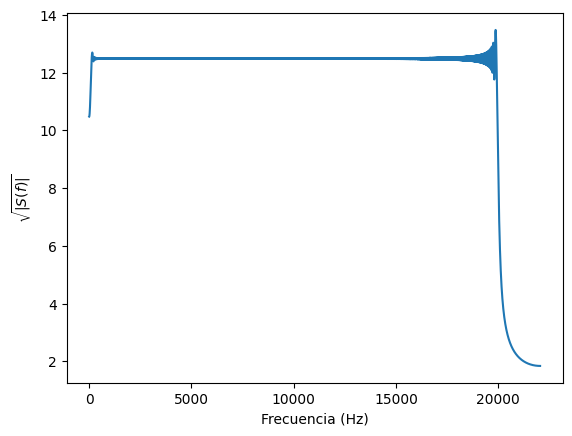

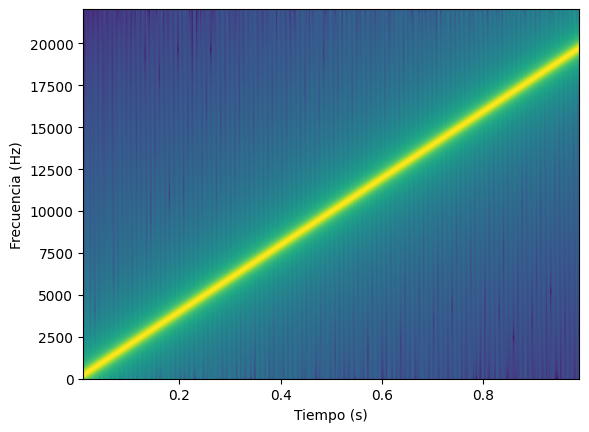

In [11]:
def plotSpecgram(x:ndarray, Fs:float, x_lim:list=None):
    # graficar el espectrograma
    fig, ax = plt.subplots(nrows=1)
    ax.specgram(x, NFFT=1024, Fs=Fs, noverlap=900)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Frecuencia (Hz)')
    if x_lim != None:
        ax.set_ylim(x_lim)
    plt.show()
    
def plotFFT(x:np.ndarray, Fs:float, x_lim:list=None):
    plt.figure()
    N2=int(len(x)/2)
    F = np.linspace(0,Fs/2,N2)
    X = np.sqrt(np.abs(np.fft.fft(x)[0:N2]))
    plt.plot(F, X)
    X[0] = 0 # remover el valor 0 que contiene el promedio de la energía de la magnitud espectral
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel(r'$\sqrt{|S(f)|}$')
    if x_lim != None:
        plt.xlim(x_lim)
    plt.show()

plotFFT(x,Fs)
plotSpecgram(x,Fs)

Para el barrido de frecuencias, vemos que la magnitud del espectro (figura de arriba) muestra una recta horizontal casi en todo el rango, indicando que todas las frecuencias están presentes; la segunda figura (espectrograma) muestra la tasa de incremento de la frecuencia en el tiempo como una recta ascendente. 

## Audio comprimido a 8 kbps

Iniciamos la compresión a 8 kbps, comprimiendo y descomprimiendo el audio mediante Opus. La frecuencia máxima representable a 8 kbps es 3200 Hz, por lo que esperamos alguna distorsión en la señal.

Skipping chunk of type "LIST", length 26


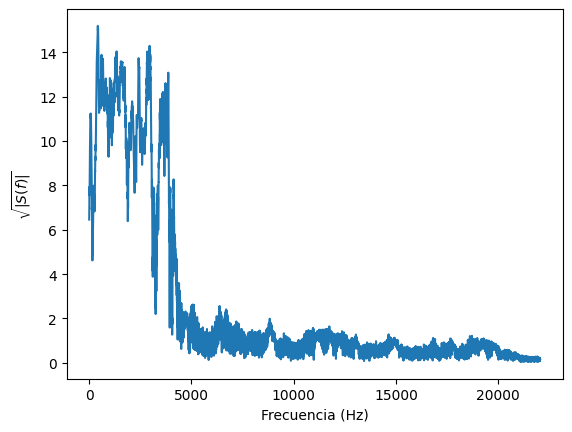

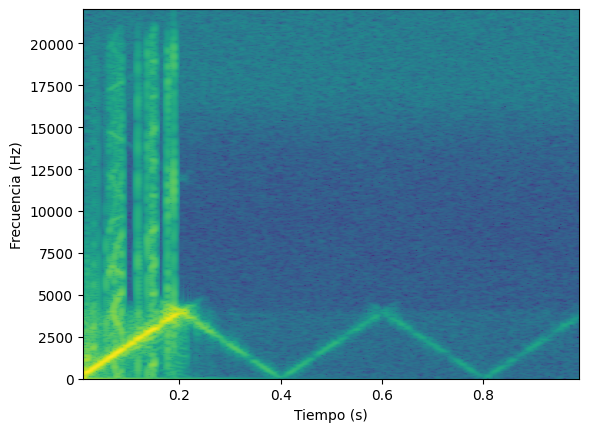

In [12]:
def readAudio(inputFile:str):
    Fs, x = wavfile.read(inputFile)
    y = np.array(x)/max(x)
    return Fs, y

# sudo apt-get install opus-tools ffmpeg
!ffmpeg -loglevel error -y -i tmp/barrido.wav -qscale 0 tmp/wavRaw.wav
!opusenc --quiet --bitrate 8 tmp/wavRaw.wav tmp/opusEnc_8kbps.opus
!opusdec --quiet tmp/opusEnc_8kbps.opus tmp/opusDec_8kbps.wav

Fs, x = readAudio('tmp/opusDec_8kbps.wav')
plotFFT(x, Fs)
plotSpecgram(x, Fs)

Audio(x, rate=Fs)

La magnitud del espectro muestra que la energía se conserva en el rango [10, 3500] Hz (pareciera incluso que llega hasta 4000 Hz), pero el resto fue atenuado, y el espectrograma muestra, además, que el rango [3500, 20000] Hz ha sufrido una distorsión llamada _aliasing_, es decir, un plegamiento de las frecuencias altas hacia abajo. Para mitigar este efecto, se puede emplear un filtro pasa-bajos antes de realizar la compresión. Apliquemos un filtrado con frecuencia de corte de 3500 Hz.

Skipping chunk of type "LIST", length 26


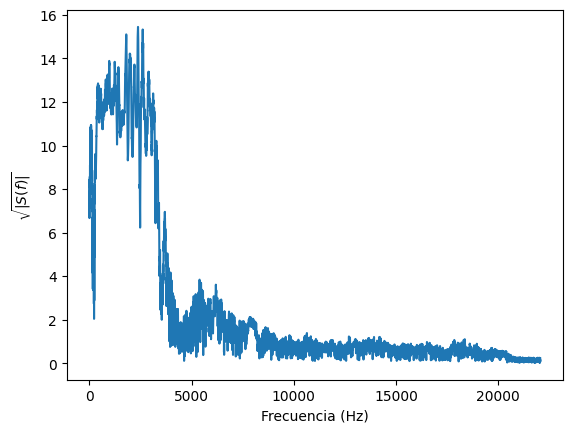

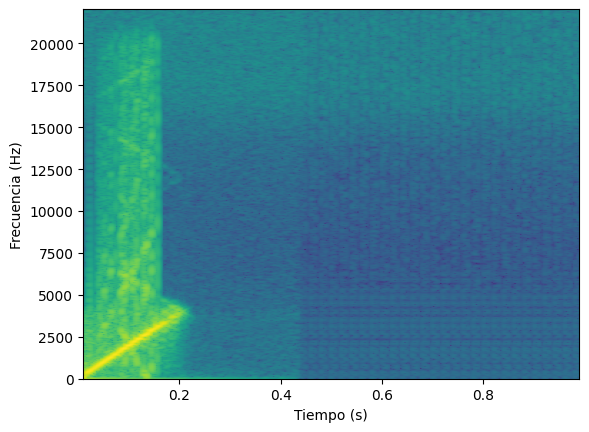

In [13]:
from scipy import signal

Fs, x = readAudio('tmp/barrido.wav')
filter_order = 30
lpf = signal.butter(filter_order, 3500, 'lp', fs=Fs, output='sos')
y = signal.sosfilt(lpf, x)
wavfile.write('tmp/barrido_filtrado.wav', int(Fs), y.astype(np.float32))

!ffmpeg -loglevel error -y -i tmp/barrido_filtrado.wav -qscale 0 tmp/wavRaw.wav # opus-tools
!opusenc --quiet --bitrate 8 tmp/wavRaw.wav tmp/opusEnc_lpf_8kbps.opus
!opusdec --quiet tmp/opusEnc_lpf_8kbps.opus tmp/opusDec_lpf_8kbps.wav

Fs, z = readAudio('tmp/opusDec_lpf_8kbps.wav')
plotFFT(z, Fs)
plotSpecgram(z, Fs)
Audio(z, rate=Fs)

En efecto, el _aliasing_ fue eliminado del espectrograma. Aunque este método funciona bien para sonidos por debajo de la frecuencia de corte elegida (corazón y pulmones), dejaría por fuera la voz humana, que contiene información hasta 20 kHz. 

## Audio comprimido a 128 kbps

Probemos ahora con 128 kbps (fullband stereo), a ver si la calidad mejora y si todavía es necesario realizar un filtrado. 

Skipping chunk of type "LIST", length 26


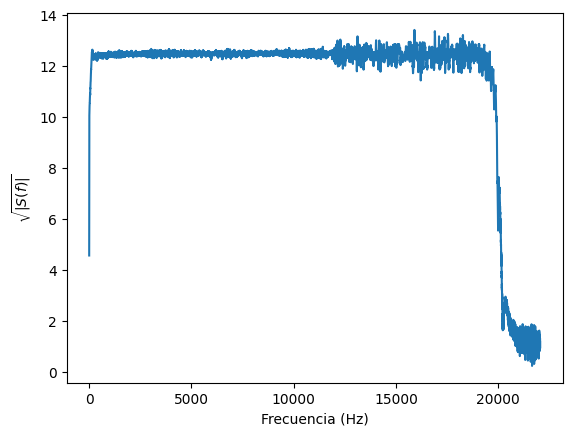

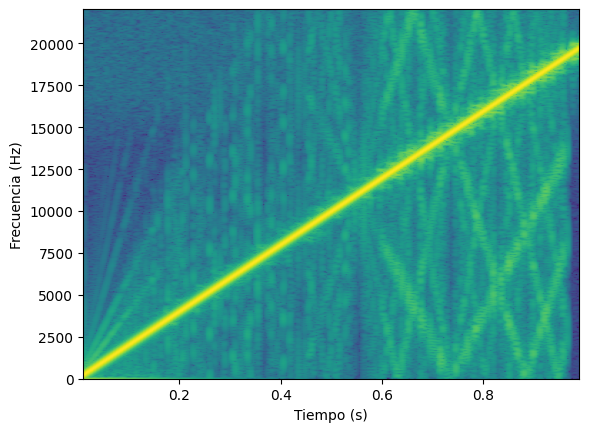

In [14]:
!ffmpeg -loglevel error -y -i tmp/barrido.wav -qscale 0 tmp/wavRaw.wav # opus-tools
!opusenc --quiet --bitrate 128 tmp/wavRaw.wav tmp/opusEnc_128kbps.opus
!opusdec --quiet tmp/opusEnc_128kbps.opus tmp/opusDec_128kbps.wav

Fs, y = readAudio('tmp/opusDec_128kbps.wav')
plotFFT(y, Fs)
plotSpecgram(y, Fs)

Audio(y, rate=Fs)

El espectrograma ha mejorado, pero sigue mostrando algunas distorsiones; al menos estas no se deben al efecto _aliasing_, pues la tasa de 128 kbps permite transmitir contenido hasta los 20 kHz (el tope del barrido), y porque el plegamiento no es simétrico respecto al eje de las ordenadas. La presencia de estas frecuencias "fantasmas" podría deberse a otras distorsiones propias de Opus. Concluimos que full-band ofrece menor distorsión que narroband, aunque la presencia de estas frecuencias fantasma podría complicar las tareas de auscultación remota.<a href="#footnote-5"><sup>5</sup></a>  

## Analizando un audio real

Para diferenciar si lo mismo ocurre con la voz, analicemos a 128 kbps una grabación real tomada de la colección _Saarbrücken Voice Database_ [16]. La grabación está en formato crudo y corresponde a un paciente masculino con reflujo gastroesofágico (GERD, por sus siglas en inglés) que pronuncia "buenos días" en alemán.

### Audio sin compresión

Escuchemos la grabación original.

**Nota: a partir de este momento se recomienda usar audífonos.**

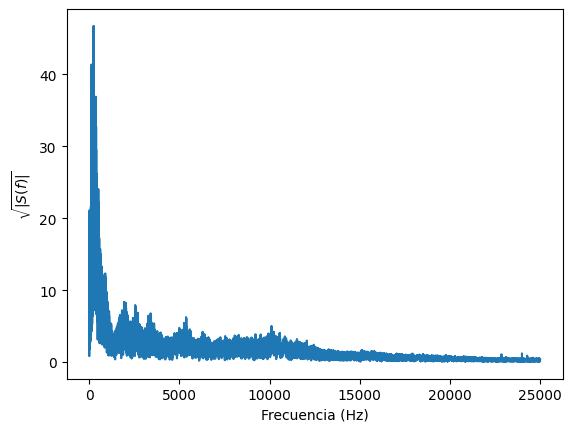

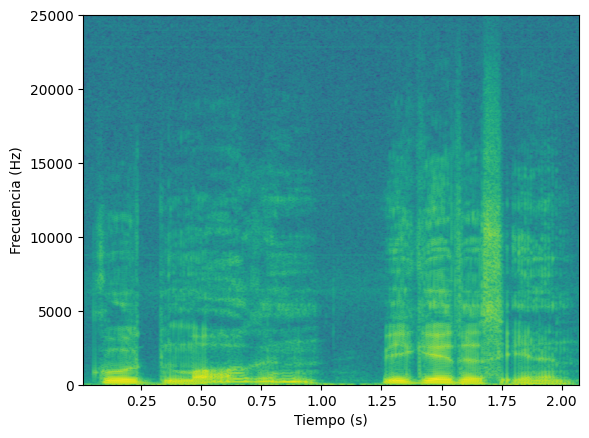

In [15]:
Fs, x = readAudio('saarbruecken_voice_database_1117-phrase.wav')
plotFFT(x,Fs)
plotSpecgram(x, Fs)

Audio(x, rate=Fs)

La grabación de referencia muestra que las armónicas son claramente reconocibles hasta los 10 kHz (algunas inclusive hasta los 15 kHz). Comprimimos ahora a 128 kbps.

Skipping chunk of type "LIST", length 26


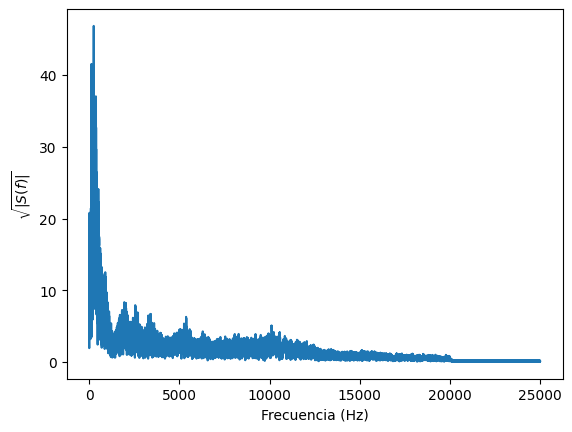

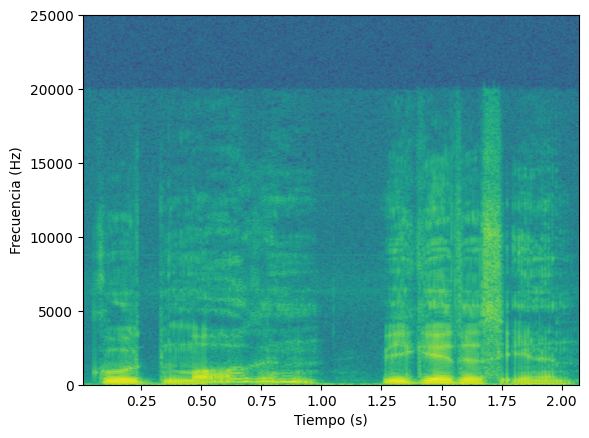

In [16]:
# Opus
!ffmpeg -loglevel error -y -i saarbruecken_voice_database_1117-phrase.wav -qscale 0 tmp/wavRaw.wav # same quality
!opusenc --quiet --bitrate 128 tmp/wavRaw.wav tmp/opusEnc.opus
!opusdec --quiet tmp/opusEnc.opus tmp/opusDec.wav

Fs, x = readAudio('tmp/opusDec.wav')
plotFFT(x,Fs)
plotSpecgram(x, Fs)

Audio(x, rate=Fs)

El espectrograma muestra que con 128 kbps los formantes siguen siendo claros y no hay presencia de frecuencias "fantasma". Esto significa que Opus podría funcionar después de todo para tareas de auscultación de la voz humana. Tal vez en esta prueba de voz Opus haya activado el modo SILK, mientras que para analizar el barrido de frecuencias haya activado el modo CELT (el barrido de frecuencias podría confundirse con música). Nos preguntamos ahora si el algoritmo considera los sonidos del corazón y los pulmones como voz o como música.

# Conclusiones

En este trabajo explicamos el problema de transmitir audio crudo para tareas de auscultación remota. Estudiamos el códec Opus como alternativa al audio crudo y explicamos por qué es un algoritmo de compresión de audio "con pérdida" y cómo realiza esa compresión a nivel psicoacústico. Realizamos dos experimentos a 8 y 128 kbps para transmitir un barrido de frecuencias y visualizamos las distorsiones obtenidas con la ayuda de la magnitud espectral y el espectrograma. A 8 kbps se observó que la grabación sufre el efecto _aliasing_ y a 128 kbps la señal es contaminada con frecuencias "fantasmas", lo cual podría resultar inconveniente si el algoritmo cataloga los sonidos del corazón y de los pulmones como música. Repetimos el experimento a 128 kbps para analizar la voz humana (con reflujo) y confirmamos que no hay distorsión significativa, por lo que 128 kbps parece conveniente para auscultar este tipo de sonidos. Como trabajo futuro, se propone analizar la distorsión en los sonidos del corazón y los pulmones, y también crear un método para cuantificar la distorsión apreciada con una prueba objetiva usando POLQA o PESQ.

# Notas
<p id="footnote-1"><sup>1</sup> El cálculo es $1{,}35 = 1 \cdot 44100 \cdot 32 / 1024^2$ Mbps.
<p id="footnote-2"><sup>2</sup> La razón por la cual elegimos estudiar Opus es porque es el algoritmo predeterminado del framework WebRTC, porque es de código libre y porque según la literatura científica ha sido empleado desde 2015 en labores de telemedicina [19]. Igualmente, la teoría explicada aquí se puede aplicar a otros códecs de compresión del audio.
<p id="footnote-3"><sup>3</sup> De acuerdo con la sugerencia de Arturo Camacho, dado que el contenido frecuencial está por debajo de 1000 Hz y suponiendo que los algoritmos de reconocimiento de patrones puedan trabajar bien en el rango [0,1000] Hz, también se podría enviar, por aparte, el audio del estetoscopio en formato crudo. De acuerdo con el teorema de Nyquist, esto significaría usar una tasa de muestreo de 2000 Hz, lo que en términos de Mbps correspondería a consumir 0,06 Mbps cada segundo (1 canal, 2000 Hz, 32 bits de cuantización, dividido por 1024 al cuadrado). Algo factible que no afectaría la calidad de la videollamada.</p>
<p id="footnote-4"><sup>4</sup> También podría haberse usado ruido blanco en lugar de un barrido de frecuencias.
<p id="footnote-5"><sup>5</sup> En este punto valdría la pena preguntarse cuál de los tres métodos de Opus realizó la compresión y si los resultados varían al forzar algún método en particular (SILK, CELT o híbrido). También sería interesante verificar el efecto de enmascaramiento de frecuencias que aplicaría Opus a dos tonos cercanos dentro de la misma banda crítica (sin que interactúen entre sí por el efecto de modulación o <a href="https://en.wikipedia.org/wiki/Beat_(acoustics)">beat modulation</a>).


# Referencias
1. Colaboradores de Wikipedia. Códec de audio [en línea]. Wikipedia, la enciclopedia libre, 2020 [fecha de consulta: 4 de noviembre del 2020]. Disponible en <https://es.wikipedia.org/w/index.php?title=C%C3%B3dec_de_audio&oldid=129362034>. 
2. Hong  Kong  Polytechnic  University. Department of Electronic and Information Engineering. Perceptual Coding and MP3. Disponible en <http://www.eie.polyu.edu.hk/~enyhchan/DAP-lab-PModel-v3.pdf>.
3. López Monfort José Javier. Opus codec | 22/23 | UPV. Universitat Politècnica de València - UPV. Disponible en <https://youtu.be/2-yv1bCDL94>. 
4. Wikipedia contributors. (2020, October 11). SILK. In Wikipedia, The Free Encyclopedia. Retrieved 15:18, November 8, 2020, from https://en.wikipedia.org/w/index.php?title=SILK&oldid=982904860
5. Wikipedia contributors. (2020, November 2). Linear predictive coding. In Wikipedia, The Free Encyclopedia. Retrieved 15:22, November 8, 2020, from https://en.wikipedia.org/w/index.php?title=Linear_predictive_coding&oldid=986664067
6. EPFL. Room impulse responses. Última vez consultado el 27 de diciembre de 2020 en: https://nbviewer.jupyter.org/github/LCAV/SignalsOfTheDay/blob/master/Room_Acoustics/Room%20Impulse%20Response.ipynb
7. López Monfort José Javier. Enmascaramiento Temporal | 4/23 | UPV. Disponible en <https://youtu.be/7NQvDoZMBM8> (consultado por última vez el 3 de enero de 2021).
8. International Telecomunication Union (ITU-T). P.800.1, MOS.
9. Julius O. Smith III, Jonathan S. Abel. Equivalent Rectangular Bandwidth. Center for Computer Research in Music and Acoustics (CCRMA), Stanford University. Disponible en <https://ccrma.stanford.edu/~jos/bbt/Equivalent_Rectangular_Bandwidth.html> (consultado por última vez el 5 de enero de 2021).
10. LCAV. Python MP3 encoder. Disponible en <https://github.com/LCAV/MP3Lab/blob/master/mp3python.ipynb> (consultado por última vez el 6 de enero de 2021).
11. XIPH ORG. OpusFAQ. Disponible en <https://wiki.xiph.org/OpusFAQ#Why_not_keep_the_SILK_and_CELT_codecs_separate.3F> (consultado por última vez el 6 de enero de 2021).
12. Tyler Abbott. How Much Data Does a Zoom Meeting Use?. Reviews ORG. Disponible en <https://www.reviews.org/internet-service/how-much-data-does-zoom-use/> (consultado por última vez el 16 de enero de 2021).
13. Xiph.Org Foundation. The Opus Codec. 135th AES Convention2013 October 17–20,  New York, USA. Disponible en <https://arxiv.org/pdf/1602.04845.pdf> (consultado por última vez el 21 de enero de 2021).
14. GROSS, V., DITTMAR, A., PENZEL, T., SCHÜTTLER, F., & von WICHERT, P. (2000). The Relationship between Normal Lung Sounds, Age, and Gender. American Journal of Respiratory and Critical Care Medicine, 162(3), 905–909. https://doi.org/10.1164/ajrccm.162.3.9905104 (consultado por última vez el 23 de enero de 2021).
15. McGee, S. (2018). Chapter 39 - Auscultation of the Heart: General Principles. In S. McGee (Ed.), Evidence-Based Physical Diagnosis (Fourth Edition) (Fourth Edition, pp. 327-332.e1). Elsevier. https://doi.org/https://doi.org/10.1016/B978-0-323-39276-1.00039-1 (consultado por última vez el 23 de enero de 2021).
16. Pützer, M., & Barry, W. J. (2008). Saarbruecken Voice Database [Data set]. Zenodo. Disponible en: <https://zenodo.org/records/16874898?preview_file=GERD.zip> (consultado por última vez el 26 de junio de 2026).
17. Carlos Cordero Pérez. Claro con precios rebajados de Internet móvil prepago en Panamá.Tecnología, El Financiero. Disponible en: <http://wvw.elfinancierocr.com/ef_archivo/2010/junio/27/tecnologia2420649.html> (consultado por última vez el 30 de enero de 2021).
18. The SciPy community. scipy.signal.butter. Disponible en: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html> (consultado por última vez el 30 de enero de 2021).
19. Jang-Jaccard, J., Nepal, S., Celler, B. et al. WebRTC-based video conferencing service for telehealth. Computing 98, 169–193 (2016). https://doi.org/10.1007/s00607-014-0429-2
20. Teledynamics. How networks affect sound quality. URL: https://info.teledynamics.com/blog/how-networks-affect-sound-quality (última vez consultado el 26 de julio de 2026).

---
<a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/"><img alt="Licencia de Creative Commons" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-nd/4.0/88x31.png" /></a><br/>Este obra está bajo una <a rel="license" href="http://creativecommons.org/licenses/by-nc-nd/4.0/">licencia de Creative Commons Reconocimiento-NoComercial-SinObraDerivada 4.0 Internacional</a>. El sitio [juanfonsecasolis.github.io](https://juanfonsecasolis.github.io) es un blog dedicado a la investigación independiente en temas relacionados al procesamiento digital de señales. Para reutilizar este artículo y citar la fuente por favor utilice el siguiente Bibtex:

```
@online{Fonseca2020,
  author = {Juan M. Fonseca-Solís},
  title = {Evaluación de la pérdida de calidad del audio usando el codec Opus en tareas de auscultación remota},
  year = 2020,
  url = {https://juanfonsecasolis.github.io/blog/JFonseca.evaluacionPerdidaCalidadAudioOpus.html},
  urldate = {}
}
```